**Assignment no.8. Model Improvement and Outlier Detection**

**AIM:
Different techniques for Detection of outliers (IQR and Z-score)
Residual Visualization
Detect multicollinearity using Variance Inflation Factor (VIF)
Improve model predictions using cleaned data.**

**LAB Experiment 1 Give python code find mean, median, mode, first quartile, second
quartile, third quartile, interquartile range and outliers for following distribution of
Scores: 55, 60, 62, 70, 75, 78, 80, 82, 85, 90. use IQR and Z-score method to detect
outliers**

In [1]:
import numpy as np
from scipy import stats

# Given distribution of Scores
scores = np.array([55, 60, 62, 70, 75, 78, 80, 82, 85, 90])

print("Scores:", scores)

Scores: [55 60 62 70 75 78 80 82 85 90]


### 1. Calculate Mean, Median, and Mode

In [6]:
# Mean
mean_score = np.mean(scores)
print(f"Mean: {mean_score:.2f}")

# Median
median_score = np.median(scores)
print(f"Median: {median_score:.2f}")

# Mode
# For discrete data, mode can be found using scipy.stats.mode
mode_result = stats.mode(scores, keepdims=False)

# Check if mode_result.count is a scalar or an array
if np.isscalar(mode_result.count):
    if mode_result.count > 1:
        print(f"Mode: {mode_result.mode}")
    else:
        print("Mode: No distinct mode (all values appear once or same number of times).")
else: # It's an array
    if mode_result.count.size > 0 and mode_result.count[0] > 1:
        print(f"Mode: {mode_result.mode[0]}")
    else:
        print("Mode: No distinct mode (all values appear once or same number of times).")

Mean: 73.70
Median: 76.50
Mode: No distinct mode (all values appear once or same number of times).


### 2. Calculate Quartiles and Interquartile Range (IQR)

In [3]:
# First Quartile (Q1 - 25th percentile)
q1 = np.percentile(scores, 25)
print(f"First Quartile (Q1): {q1:.2f}")

# Second Quartile (Q2 - 50th percentile, which is also the Median)
q2 = np.percentile(scores, 50)
print(f"Second Quartile (Q2 - Median): {q2:.2f}")

# Third Quartile (Q3 - 75th percentile)
q3 = np.percentile(scores, 75)
print(f"Third Quartile (Q3): {q3:.2f}")

# Interquartile Range (IQR = Q3 - Q1)
iqr = q3 - q1
print(f"Interquartile Range (IQR): {iqr:.2f}")

First Quartile (Q1): 64.00
Second Quartile (Q2 - Median): 76.50
Third Quartile (Q3): 81.50
Interquartile Range (IQR): 17.50


### 3. Outlier Detection using IQR Method

In [4]:
# Calculate the lower and upper bounds for outlier detection
lower_bound_iqr = q1 - 1.5 * iqr
upper_bound_iqr = q3 + 1.5 * iqr

print(f"IQR Lower Bound: {lower_bound_iqr:.2f}")
print(f"IQR Upper Bound: {upper_bound_iqr:.2f}")

# Identify outliers using IQR method
outliers_iqr = [score for score in scores if score < lower_bound_iqr or score > upper_bound_iqr]

if outliers_iqr:
    print("Outliers (IQR method):", outliers_iqr)
else:
    print("No outliers detected using the IQR method.")

IQR Lower Bound: 37.75
IQR Upper Bound: 107.75
No outliers detected using the IQR method.


### 4. Outlier Detection using Z-score Method

In [5]:
# Calculate Z-scores for each data point
z_scores = np.abs(stats.zscore(scores))

print("Z-scores:", z_scores)

# Define a threshold for outlier detection (commonly 2 or 3)
z_score_threshold = 2.0 # A common threshold, can be adjusted

# Identify outliers using Z-score method
outliers_zscore = scores[z_scores > z_score_threshold]

if outliers_zscore.size > 0:
    print(f"Outliers (Z-score method with threshold {z_score_threshold}):", outliers_zscore)
else:
    print(f"No outliers detected using the Z-score method with threshold {z_score_threshold}.")

Z-scores: [1.69992976 1.24540308 1.06359241 0.33634974 0.11817693 0.39089294
 0.57270361 0.75451428 1.02723028 1.48175695]
No outliers detected using the Z-score method with threshold 2.0.


**LAB Experiment 2. Give python code find mean, median, mode, first quartile, second
quartile, third quartile, interquartile range and outliers for following distribution of
Scores: 55, 60, 62, 70, 75, 78, 80, 82, 1000, 5000. use all techniques to detect outliers.**

In [7]:
import numpy as np
from scipy import stats

# Given distribution of Scores for LAB Experiment 2
scores_exp2 = np.array([55, 60, 62, 70, 75, 78, 80, 82, 1000, 5000])

print("Scores for Experiment 2:", scores_exp2)

Scores for Experiment 2: [  55   60   62   70   75   78   80   82 1000 5000]


### 1. Calculate Mean, Median, and Mode for Experiment 2

In [8]:
# Mean
mean_score_exp2 = np.mean(scores_exp2)
print(f"Mean: {mean_score_exp2:.2f}")

# Median
median_score_exp2 = np.median(scores_exp2)
print(f"Median: {median_score_exp2:.2f}")

# Mode
mode_result_exp2 = stats.mode(scores_exp2, keepdims=False)

if np.isscalar(mode_result_exp2.count):
    if mode_result_exp2.count > 1:
        print(f"Mode: {mode_result_exp2.mode}")
    else:
        print("Mode: No distinct mode (all values appear once or same number of times).")
else: # It's an array
    if mode_result_exp2.count.size > 0 and mode_result_exp2.count[0] > 1:
        print(f"Mode: {mode_result_exp2.mode[0]}")
    else:
        print("Mode: No distinct mode (all values appear once or same number of times).")

Mean: 656.20
Median: 76.50
Mode: No distinct mode (all values appear once or same number of times).


### 2. Calculate Quartiles and Interquartile Range (IQR) for Experiment 2

In [9]:
# First Quartile (Q1 - 25th percentile)
q1_exp2 = np.percentile(scores_exp2, 25)
print(f"First Quartile (Q1): {q1_exp2:.2f}")

# Second Quartile (Q2 - 50th percentile, which is also the Median)
q2_exp2 = np.percentile(scores_exp2, 50)
print(f"Second Quartile (Q2 - Median): {q2_exp2:.2f}")

# Third Quartile (Q3 - 75th percentile)
q3_exp2 = np.percentile(scores_exp2, 75)
print(f"Third Quartile (Q3): {q3_exp2:.2f}")

# Interquartile Range (IQR = Q3 - Q1)
iqr_exp2 = q3_exp2 - q1_exp2
print(f"Interquartile Range (IQR): {iqr_exp2:.2f}")

First Quartile (Q1): 64.00
Second Quartile (Q2 - Median): 76.50
Third Quartile (Q3): 81.50
Interquartile Range (IQR): 17.50


### 3. Outlier Detection using IQR Method for Experiment 2

In [10]:
# Calculate the lower and upper bounds for outlier detection
lower_bound_iqr_exp2 = q1_exp2 - 1.5 * iqr_exp2
upper_bound_iqr_exp2 = q3_exp2 + 1.5 * iqr_exp2

print(f"IQR Lower Bound: {lower_bound_iqr_exp2:.2f}")
print(f"IQR Upper Bound: {upper_bound_iqr_exp2:.2f}")

# Identify outliers using IQR method
outliers_iqr_exp2 = [score for score in scores_exp2 if score < lower_bound_iqr_exp2 or score > upper_bound_iqr_exp2]

if outliers_iqr_exp2:
    print("Outliers (IQR method):", outliers_iqr_exp2)
else:
    print("No outliers detected using the IQR method.")

IQR Lower Bound: 37.75
IQR Upper Bound: 107.75
Outliers (IQR method): [np.int64(1000), np.int64(5000)]


### 4. Outlier Detection using Z-score Method for Experiment 2

In [11]:
# Calculate Z-scores for each data point
z_scores_exp2 = np.abs(stats.zscore(scores_exp2))

print("Z-scores:", z_scores_exp2)

# Define a threshold for outlier detection (commonly 2 or 3)
z_score_threshold_exp2 = 2.0 # A common threshold, can be adjusted

# Identify outliers using Z-score method
outliers_zscore_exp2 = scores_exp2[z_scores_exp2 > z_score_threshold_exp2]

if outliers_zscore_exp2.size > 0:
    print(f"Outliers (Z-score method with threshold {z_score_threshold_exp2}):", outliers_zscore_exp2)
else:
    print(f"No outliers detected using the Z-score method with threshold {z_score_threshold_exp2}.")

Z-scores: [0.40779976 0.40440821 0.40305159 0.39762512 0.39423357 0.39219864
 0.39084202 0.3894854  0.23320286 2.94644145]
Outliers (Z-score method with threshold 2.0): [5000]


**LAB Experiment 3. Find Inter-quartile range manually for the following dataset
data = [5, 8, 15, 26, 10, 18, 3, 12, 6, 14, 11]**

### Manually Calculating Inter-Quartile Range (IQR)

To find the Inter-Quartile Range (IQR) manually for a given dataset, follow these steps:

1.  **Sort the data:** Arrange all data points in ascending order.
2.  **Find the Median (Q2):** This is the middle value of the sorted dataset. If there's an odd number of data points, it's the single middle value. If there's an even number, it's the average of the two middle values.
3.  **Find the First Quartile (Q1):** This is the median of the lower half of the dataset (all values below Q2). If the dataset has an odd number of values, exclude Q2 itself from both halves when splitting.
4.  **Find the Third Quartile (Q3):** This is the median of the upper half of the dataset (all values above Q2). If the dataset has an odd number of values, exclude Q2 itself from both halves when splitting.
5.  **Calculate the IQR:** Subtract Q1 from Q3: `IQR = Q3 - Q1`.

In [12]:
import numpy as np

# Given dataset
data = [5, 8, 15, 26, 10, 18, 3, 12, 6, 14, 11]
print("Original Data:", data)

# Step 1: Sort the data
sorted_data = sorted(data)
print("Sorted Data:", sorted_data)

n = len(sorted_data)

# Step 2: Find the Median (Q2)
# Using numpy's percentile for consistency, but you can also manually find it.
# For n=11, the median is the (11+1)/2 = 6th element (index 5)
q2_manual = sorted_data[n // 2] # Integer division gives index 5
# Or using numpy: np.median(sorted_data)
print(f"Median (Q2): {q2_manual}")

# Split the data into lower and upper halves (excluding Q2 for odd n)
lower_half = sorted_data[:n // 2] # Elements before index 5
upper_half = sorted_data[n // 2 + 1:] # Elements after index 5

print("Lower Half:", lower_half)
print("Upper Half:", upper_half)

# Step 3: Find the First Quartile (Q1) - Median of the lower half
# For lower_half = [3, 5, 6, 8, 10], median is 6
q1_manual = np.median(lower_half)
print(f"First Quartile (Q1): {q1_manual}")

# Step 4: Find the Third Quartile (Q3) - Median of the upper half
# For upper_half = [12, 14, 15, 18, 26], median is 15
q3_manual = np.median(upper_half)
print(f"Third Quartile (Q3): {q3_manual}")

# Step 5: Calculate the IQR
iqr_manual = q3_manual - q1_manual
print(f"Inter-Quartile Range (IQR): {iqr_manual}")

# Verification using numpy's built-in function
iqr_numpy = np.percentile(data, 75) - np.percentile(data, 25)
print(f"IQR (using numpy for verification): {iqr_numpy}")

Original Data: [5, 8, 15, 26, 10, 18, 3, 12, 6, 14, 11]
Sorted Data: [3, 5, 6, 8, 10, 11, 12, 14, 15, 18, 26]
Median (Q2): 11
Lower Half: [3, 5, 6, 8, 10]
Upper Half: [12, 14, 15, 18, 26]
First Quartile (Q1): 6.0
Third Quartile (Q3): 15.0
Inter-Quartile Range (IQR): 9.0
IQR (using numpy for verification): 7.5


**LAB Experiment 4. Generate two random datasets and using seaborn plot box plot and
voilen plot for the datasets**

In [13]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Generate two random datasets
# Dataset 1: Normal distribution (e.g., control group)
data1 = np.random.normal(loc=70, scale=10, size=200) # mean=70, std=10, 200 samples

# Dataset 2: Normal distribution with a different mean and slightly more spread (e.g., experimental group)
data2 = np.random.normal(loc=75, scale=15, size=200) # mean=75, std=15, 200 samples

print("Generated Data 1 (first 5 elements):", data1[:5])
print("Generated Data 2 (first 5 elements):", data2[:5])

Generated Data 1 (first 5 elements): [66.92054103 80.82840075 68.55464888 90.3674438  68.3564463 ]
Generated Data 2 (first 5 elements): [81.36042248 55.61556601 56.70661666 87.33774469 68.06615495]


### Box Plot Visualization

A box plot (or box-and-whisker plot) displays the distribution of quantitative data in a way that facilitates comparisons between variables or across categories. It shows the median, quartiles (Q1 and Q3), and potential outliers.


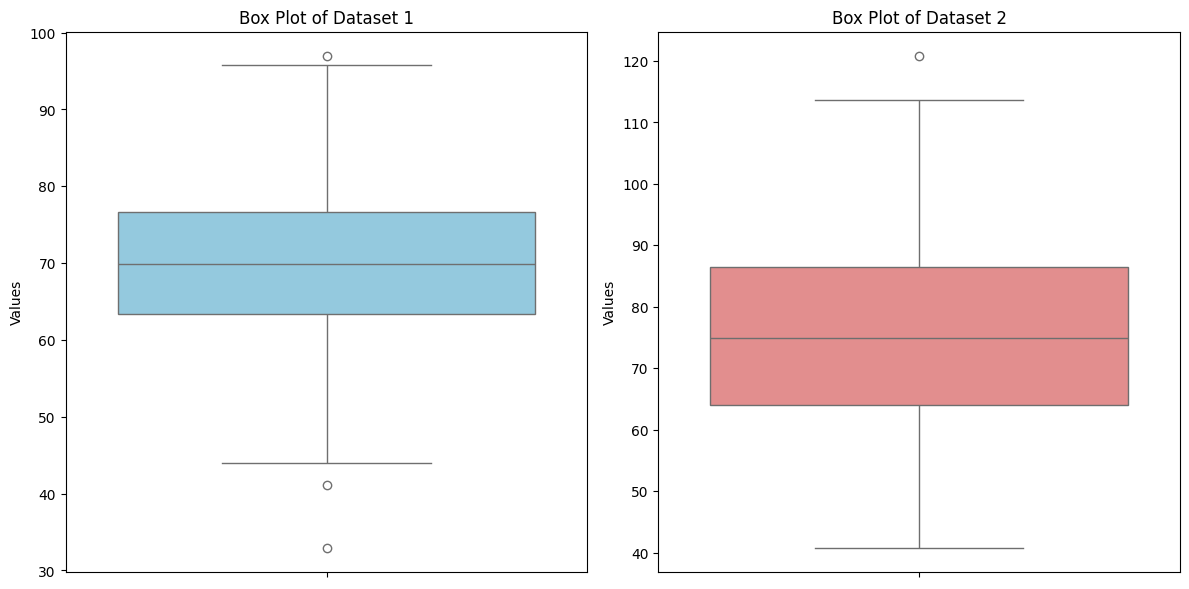

In [14]:
# Create a figure with two subplots for box plots
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.boxplot(y=data1, color='skyblue')
plt.title('Box Plot of Dataset 1')
plt.ylabel('Values')

plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.boxplot(y=data2, color='lightcoral')
plt.title('Box Plot of Dataset 2')
plt.ylabel('Values')

plt.tight_layout()
plt.show()

### Violin Plot Visualization

A violin plot is similar to a box plot but also shows the probability density of the data at different values, usually smoothed by a kernel density estimator. It's particularly useful for visualizing the distribution shape and density.


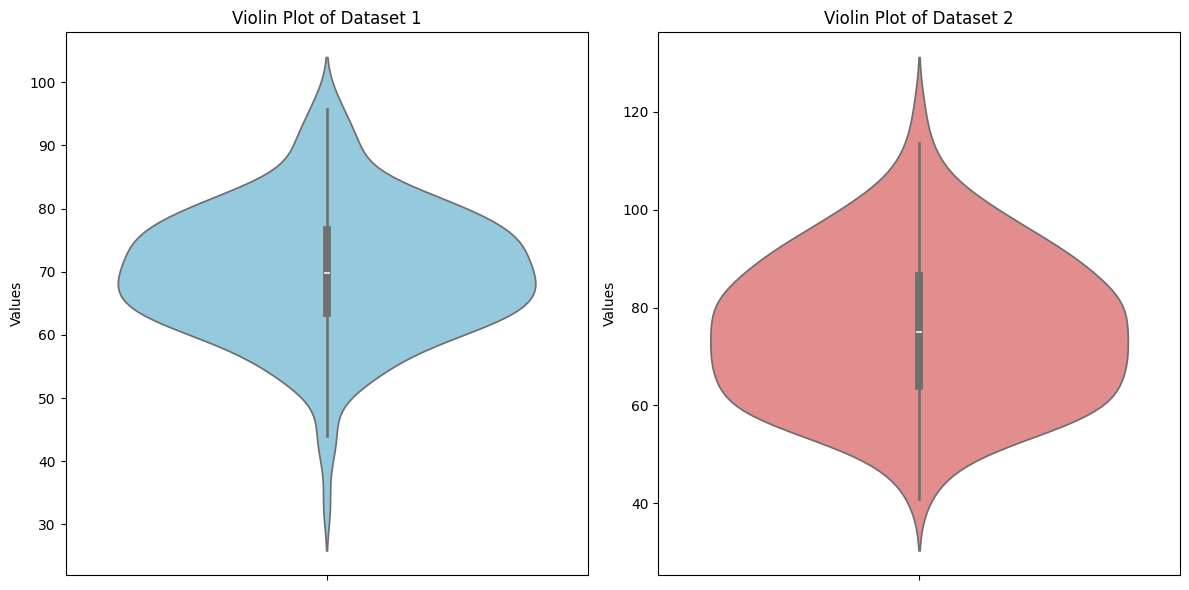

In [15]:
# Create a figure with two subplots for violin plots
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.violinplot(y=data1, color='skyblue')
plt.title('Violin Plot of Dataset 1')
plt.ylabel('Values')

plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.violinplot(y=data2, color='lightcoral')
plt.title('Violin Plot of Dataset 2')
plt.ylabel('Values')

plt.tight_layout()
plt.show()

**LAB Experiment 5. Detect multicollinearity using Variance Inflation Factor (VIF) for
the given dataset ‘vif_data.csv’ . Also plot residual plot for Ambience v/s Offers for data.**

In [16]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.regression.linear_model import OLS
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# --- Create a dummy vif_data.csv for demonstration if it doesn't exist ---
try:
    df = pd.read_csv('vif_data.csv')
    print("vif_data.csv loaded successfully.")
except FileNotFoundError:
    print("vif_data.csv not found. Generating a sample CSV file.")
    # Generate sample data with some correlations
    np.random.seed(42)
    n_samples = 100

    # Independent variables
    ambience = np.random.normal(loc=7, scale=1.5, size=n_samples)
    offers = np.random.normal(loc=5, scale=1, size=n_samples)
    price = 0.6 * ambience + 0.3 * offers + np.random.normal(loc=20, scale=3, size=n_samples) # price is correlated with ambience and offers
    service_quality = 0.4 * offers + np.random.normal(loc=8, scale=0.8, size=n_samples)

    # Dependent variable (for residual plot context, though not directly used in VIF calculation)
    dependent_var = 2 * ambience + 1.5 * offers - 0.5 * price + np.random.normal(loc=50, scale=5, size=n_samples)

    data = {
        'Ambience': ambience,
        'Offers': offers,
        'Price': price,
        'Service_Quality': service_quality,
        'Dependent_Var': dependent_var # A dummy dependent variable
    }
    df = pd.DataFrame(data)
    df.to_csv('vif_data.csv', index=False)
    print("Sample 'vif_data.csv' created and loaded.")

display(df.head())

vif_data.csv not found. Generating a sample CSV file.
Sample 'vif_data.csv' created and loaded.


,Ambience,Offers,Price,Service_Quality,Dependent_Var
0,7.745071,3.584629,26.795794,8.770656,49.497051
1,6.792604,4.579355,27.131722,9.383597,53.891503
2,7.971533,4.657285,29.429259,10.460749,58.240583
3,9.284545,4.197723,29.991450,10.167385,60.104852
4,6.648770,4.838714,21.307868,9.918764,57.651350


### Detect Multicollinearity using Variance Inflation Factor (VIF)

VIF quantifies the severity of multicollinearity in an ordinary least squares regression analysis. It measures how much the variance of an estimated regression coefficient is inflated due to multicollinearity. A VIF value:
*   **1:** No correlation between the predictor and other predictors.
*   **1 to 5:** Moderately correlated.
*   **> 5 or > 10:** Highly correlated, indicating multicollinearity issues.


In [17]:
# Select independent variables for VIF calculation
X = df[['Ambience', 'Offers', 'Price', 'Service_Quality']]

# Add a constant to the independent variables matrix
X_const = sm.add_constant(X)

# Calculate VIF for each independent variable
vif_data = pd.DataFrame()
vif_data["feature"] = X_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]

print("Variance Inflation Factor (VIF) scores:")
display(vif_data.round(2))

Variance Inflation Factor (VIF) scores:


,feature,VIF
0,const,251.91
1,Ambience,1.26
2,Offers,1.28
3,Price,1.20
4,Service_Quality,1.31


### Plot Residual Plot for Ambience vs. Offers

A residual plot displays the residuals (the differences between observed and predicted values) on the y-axis and the independent variable (or predicted values) on the x-axis. It helps in checking the assumptions of linearity, homoscedasticity, and independence of errors in a regression model.

For this plot, we'll fit a simple linear regression model where 'Offers' is the dependent variable and 'Ambience' is the independent variable, and then plot the residuals of this model against 'Ambience'.

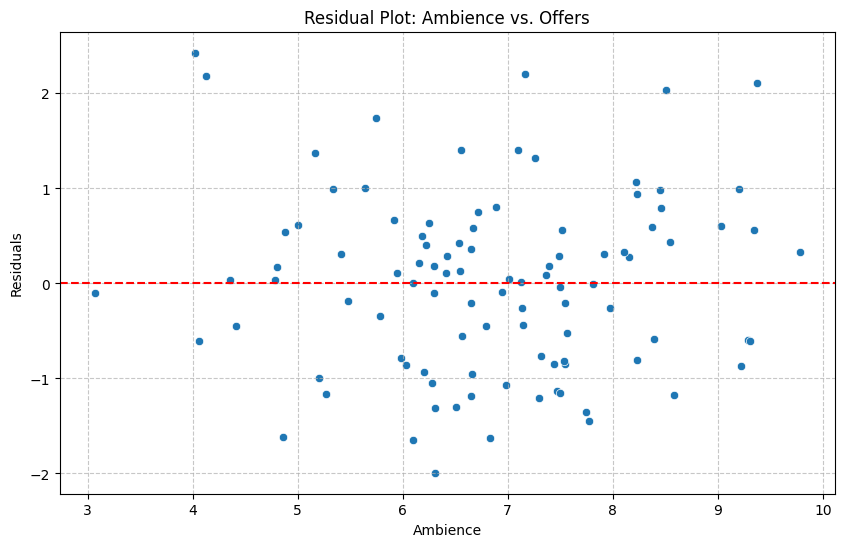

Summary of the regression model (Offers ~ Ambience):
                            OLS Regression Results                            
Dep. Variable:                 Offers   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     1.858
Date:                Thu, 07 May 2026   Prob (F-statistic):              0.176
Time:                        18:46:49   Log-Likelihood:                -135.71
No. Observations:                 100   AIC:                             275.4
Df Residuals:                      98   BIC:                             280.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

In [18]:
# Fit a simple linear regression model: Offers ~ Ambience
# Add a constant to the independent variable for the intercept
X_ambience = sm.add_constant(df['Ambience'])
y_offers = df['Offers']

model = OLS(y_offers, X_ambience)
results = model.fit()

# Calculate residuals
residuals = results.resid

# Plotting the residual plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['Ambience'], y=residuals)
plt.axhline(y=0, color='r', linestyle='--') # Add a horizontal line at 0 for reference
plt.title('Residual Plot: Ambience vs. Offers')
plt.xlabel('Ambience')
plt.ylabel('Residuals')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print("Summary of the regression model (Offers ~ Ambience):")
print(results.summary())